# Auracelle Mathematical Verification & Validation Test Harness

**Gold-standard reference dataset for Strata I-IV**, to be run against every Auracelle
implementation (Lyra, WinterStorm2030, StressPoint, Orion, ...).

Every expected value in this notebook was **hand-derived first**, before any code ran
against it (see the "Hand derivation" text under each case). The code is what's on trial —
not the numbers below it.

This notebook separates two questions throughout, per the methodological review that
prompted it:

- **Verification** — "Is the mathematics implemented correctly?"
- **Validation** — "Does the mathematics actually represent governance capacity in a
  defensible way?"

Sections:
1. Stratum I — Narrow Operational Factor (logistic score): equation verification,
   boundary tests, monotonicity, saturation safety
2. Stratum II — Domain aggregation *(⚠ assumption-flagged — not formally disclosed)*
3. Stratum III — Composite (g-GWC): additive vs. multiplicative divergence
4. Stratum IV — Environmental (EOC) modulation
5. Level 4 — Scenario / face validation bank (6 designed cases)
6. Level 5 — Monte Carlo weight-sensitivity robustness testing
7. Summary report


In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from harness_core import (
    nof_score, domain_score, composite_additive, composite_multiplicative,
    apply_environment, monte_carlo_ranking_sensitivity,
)
from test_cases import (
    STRATUM_I_CASES, STRATUM_II_CASES, STRATUM_III_CASES, STRATUM_IV_CASES,
    SCENARIO_BANK, SCENARIO_BETAS, EXPECTED_ORDERINGS,
)

results = []
def check(case_id, description, expected, actual, tol, assumption_flagged, stratum):
    passed = abs(expected - actual) <= tol
    results.append(dict(id=case_id, stratum=stratum, description=description,
                         expected=expected, actual=actual, diff=actual-expected,
                         tolerance=tol, passed=passed, assumption_flagged=assumption_flagged))
    status = "PASS" if passed else "FAIL"
    flag = " [ASSUMPTION]" if assumption_flagged else ""
    print(f"[{status}]{flag} {case_id}: expected={expected:.6f} actual={actual:.6f} diff={actual-expected:+.2e}")
    return passed


## 1. Stratum I — Narrow Operational Factor

`NOF = sigma(w^T X - theta)`, `sigma(z) = 1 / (1 + e^-z)`

Test order: (1) equation verification against hand calculation, (2) boundary behavior
at 0/1/exact-threshold, (3) monotonicity — does raising an indicator always raise the
score, and does a higher-weight indicator move the score more, (4) saturation safety
for extreme inputs.


In [2]:
print("=== Stratum I: equation verification & boundary tests ===\n")
for c in STRATUM_I_CASES:
    print(f">>> {c['id']}: {c['description']}")
    print(f"    Hand derivation:\n    " + c['derivation'].replace('\n', '\n    '))
    actual, z = nof_score(c['X'], c['w'], c['theta'])
    check(c['id'], c['description'], c['expected'], actual, c['tolerance'], c['assumption_flagged'], 'I')
    print()


=== Stratum I: equation verification & boundary tests ===

>>> I-1_baseline: Baseline case from the reviewer's worked example.
    Hand derivation:
    w.X = .5(.8)+.3(.6)+.2(.4) = .40+.18+.08 = .66
    z = .66 - .50 = .16
    NOF = 1/(1+e^-.16) ≈ 0.5399
[PASS] I-1_baseline: expected=0.539915 actual=0.539915 diff=-1.15e-07

>>> I-2_all_zero_inputs: Boundary: all indicators at 0.
    Hand derivation:
    w.X = 0; z = 0 - .5 = -.5; NOF = 1/(1+e^.5) ≈ 0.3775
[PASS] I-2_all_zero_inputs: expected=0.377541 actual=0.377541 diff=-3.31e-07

>>> I-3_all_one_inputs: Boundary: all indicators at 1 (weights sum to 1.0).
    Hand derivation:
    w.X = .5+.3+.2 = 1.0; z = 1.0-.5 = .5; NOF = 1/(1+e^-.5) ≈ 0.6225
[PASS] I-3_all_one_inputs: expected=0.622459 actual=0.622459 diff=+3.31e-07

>>> I-4_theta_zero_midpoint: theta=0 with X all at 0.5: should equal case I-3's z (both z=.5).
    Hand derivation:
    w.X = .5(1.0) = .5; z = .5-0 = .5; NOF = same as I-3 ≈ 0.6225
[PASS] I-4_theta_zero_midpoint: expe

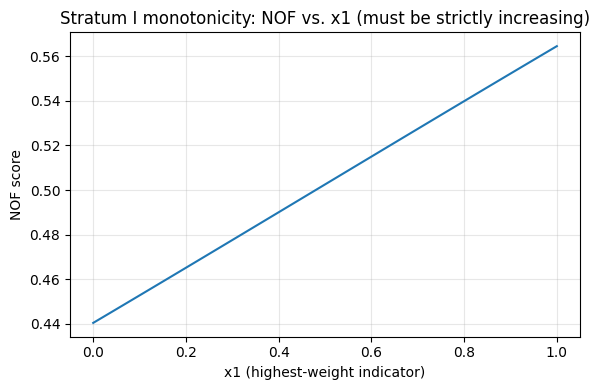

Strictly monotonic across full sweep: True


In [3]:
# Monotonicity check, visualized: does NOF increase monotonically as x1 sweeps 0->1?
w, theta = [0.5, 0.3, 0.2], 0.5
x1_sweep = np.linspace(0, 1, 50)
nof_sweep = [nof_score([x1, 0.6, 0.4], w, theta)[0] for x1 in x1_sweep]

plt.figure(figsize=(6, 4))
plt.plot(x1_sweep, nof_sweep)
plt.xlabel('x1 (highest-weight indicator)')
plt.ylabel('NOF score')
plt.title('Stratum I monotonicity: NOF vs. x1 (must be strictly increasing)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('stratum_I_monotonicity.png', dpi=110)
plt.show()

is_monotonic = all(b >= a for a, b in zip(nof_sweep, nof_sweep[1:]))
print(f"Strictly monotonic across full sweep: {is_monotonic}")


## 2. Stratum II — Domain (BGC) Aggregation ⚠ ASSUMPTION-FLAGGED

**The source material does not formally specify a Stratum II (NOF → Domain) aggregation
equation** — only that NOFs "aggregate into" a domain score. Stratum I (logistic NOF) and
Stratum III (additive/multiplicative composite) both have explicit disclosed equations;
this layer does not.

This notebook implements Stratum II as a **weighted arithmetic mean** of a domain's NOF
scores (placeholder). Treat any failure here as "the assumption needs confirming,"
not "the code is broken" — and treat a pass here as "internally consistent with the
placeholder," not as validation of the real formula.


In [4]:
print("=== Stratum II: domain aggregation [ASSUMPTION-FLAGGED] ===\n")
for c in STRATUM_II_CASES:
    print(f">>> {c['id']}: {c['description']}")
    print(f"    Hand derivation: {c['derivation']}")
    actual = domain_score(c['nof_scores'], c['sub_weights'])
    check(c['id'], c['description'], c['expected'], actual, c['tolerance'], c['assumption_flagged'], 'II')
    print()


=== Stratum II: domain aggregation [ASSUMPTION-FLAGGED] ===

>>> II-8_equal_weight_domain_mean: [ASSUMPTION-FLAGGED] Equal-weighted mean of 3 NOF scores into one domain.
    Hand derivation: (0.54 + 0.6225 + 0.5) / 3 = 1.6625 / 3 ≈ 0.5542
[PASS] [ASSUMPTION] II-8_equal_weight_domain_mean: expected=0.554167 actual=0.554167 diff=-3.33e-07

>>> II-9_explicit_weighted_domain_mean: [ASSUMPTION-FLAGGED] Explicitly-weighted mean, mirroring Stratum I's own weighting pattern.
    Hand derivation: (.5)(.8)+(.3)(.6)+(.2)(.4) = .40+.18+.08 = 0.66 exactly
[PASS] [ASSUMPTION] II-9_explicit_weighted_domain_mean: expected=0.660000 actual=0.660000 diff=-1.11e-16



## 3. Stratum III — Composite (g-GWC): Additive vs. Multiplicative

This is **the single most important methodological question in the whole architecture**,
per the review: additive and multiplicative aggregation are not two notations for the
same thing — they encode different theories of governance (compensable weakness vs.
weak-domain-constrained capacity). Which one is "correct" should be a modeling decision,
not an artifact of which formula happened to be coded first.


In [5]:
print("=== Stratum III: additive vs. multiplicative ===\n")
comparison_rows = []
for c in STRATUM_III_CASES:
    print(f">>> {c['id']}: {c['description']}")
    print(f"    Hand derivation:\n    " + c['derivation'].replace('\n', '\n    '))
    add = composite_additive(c['domain_scores'], c['betas'])
    mult = composite_multiplicative(c['domain_scores'], c['betas'])
    check(c['id']+'_additive', c['description'], c['expected_additive'], add, c['tolerance'], c['assumption_flagged'], 'III')
    check(c['id']+'_multiplicative', c['description'], c['expected_multiplicative'], mult, c['tolerance'], c['assumption_flagged'], 'III')
    comparison_rows.append(dict(case=c['id'], domains=str(c['domain_scores']), additive=add, multiplicative=mult, gap=add-mult))
    print()

comp_df = pd.DataFrame(comparison_rows)
comp_df


=== Stratum III: additive vs. multiplicative ===

>>> III-10_additive_vs_multiplicative_collapse_demo: The reviewer's own example: one weak domain (.3) among two strong ones (.9, .9), equal weights. Demonstrates the two aggregation forms encode DIFFERENT governance theories, not the same math.
    Hand derivation:
    Additive: (.9+.9+.3)/3 = .70
    Multiplicative: (.9 x .9 x .3)^(1/3) = (.243)^(1/3) ≈ 0.6240
    Gap ≈ 0.076 — the weak domain hurts the geometric form much more.
[PASS] III-10_additive_vs_multiplicative_collapse_demo_additive: expected=0.700000 actual=0.700000 diff=+0.00e+00
[PASS] III-10_additive_vs_multiplicative_collapse_demo_multiplicative: expected=0.624025 actual=0.624025 diff=+1.47e-07

>>> III-11_equal_domains_convergence: Sanity check: when all domains are equal, additive and multiplicative MUST agree exactly.
    Hand derivation:
    Additive: .7. Multiplicative: (.343)^(1/3) = .7. They must match exactly.
[PASS] III-11_equal_domains_convergence_additive: expe

,case,domains,additive,multiplicative,gap
0,III-10_additive_vs_multiplicative_collapse_demo,"[0.9, 0.9, 0.3]",0.700000,0.624025,7.597485e-02
1,III-11_equal_domains_convergence,"[0.7, 0.7, 0.7]",0.700000,0.700000,1.110223e-16
2,III-12_near_zero_collapse,"[0.99, 0.99, 0.01]",0.663333,0.214005,4.493286e-01
3,III-13_unequal_weights,"[0.8, 0.6, 0.4]",0.660000,0.638855,2.114490e-02


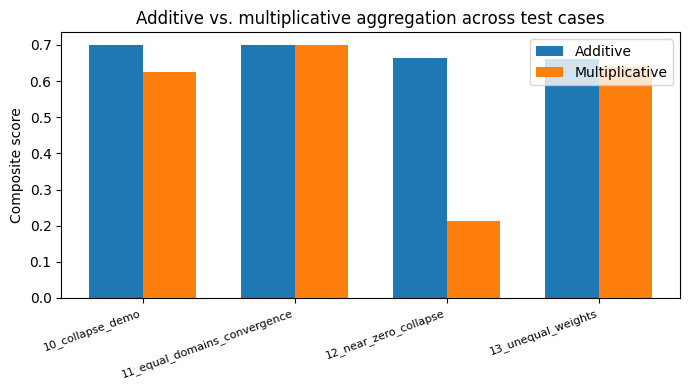

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(comp_df))
width = 0.35
ax.bar(x - width/2, comp_df['additive'], width, label='Additive')
ax.bar(x + width/2, comp_df['multiplicative'], width, label='Multiplicative')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['case'].str.replace('III-', '').str.replace('_additive_vs_multiplicative', ''), rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Composite score')
ax.set_title('Additive vs. multiplicative aggregation across test cases')
ax.legend()
plt.tight_layout()
plt.savefig('stratum_III_additive_vs_multiplicative.png', dpi=110)
plt.show()


## 4. Stratum IV — Environmental (EOC) Modulation

`AdjustedDomain = Domain * EOC`, with `EOC = 1.0` meaning no physical-environment
dependency. As the review noted, this is worth interrogating conceptually: is EOC
measuring *institutional capacity*, *realized performance*, or *external difficulty*?
They're subtly different constructs.


In [7]:
print("=== Stratum IV: environmental modulation ===\n")
for c in STRATUM_IV_CASES:
    print(f">>> {c['id']}: {c['description']}")
    print(f"    Hand derivation: {c['derivation']}")
    actual = apply_environment(c['domain_scores'], c['eoc_coeffs'])
    for i, (exp_i, act_i) in enumerate(zip(c['expected'], actual)):
        check(f"{c['id']}_dom{i}", c['description'], exp_i, act_i, c['tolerance'], c['assumption_flagged'], 'IV')
    print()


=== Stratum IV: environmental modulation ===

>>> IV-14_half_environment: Reviewer's own example: a hostile environment (EOC=.5) cuts realized capacity in half.
    Hand derivation: AdjustedDomain = .80 x .50 = 0.40
[PASS] IV-14_half_environment_dom0: expected=0.400000 actual=0.400000 diff=+0.00e+00

>>> IV-15_no_environment_dependency: Sanity check: EOC=1.0 (no physical dependency) must leave the domain score unchanged.
    Hand derivation: AdjustedDomain = .80 x 1.00 = 0.80 (unchanged)
[PASS] IV-15_no_environment_dependency_dom0: expected=0.800000 actual=0.800000 diff=+0.00e+00

>>> IV-16_weak_domain_mild_environment_compounding: An already-weak domain (.3) under only a mild environmental penalty (.9) is further reduced.
    Hand derivation: AdjustedDomain = .30 x .90 = 0.27
[PASS] IV-16_weak_domain_mild_environment_compounding_dom0: expected=0.270000 actual=0.270000 diff=+0.00e+00



## 5. Level 4 — Scenario / Face Validation Bank

Six deliberately designed governance scenarios. There's no single "correct" numeric
target here — the question is whether the mathematics produces a **ranking** that a
domain expert would find plausible.

⚠ `S4_weak_institutions_favorable_environment` uses EOC = 1.1 (mild enhancement above
unity). The source material says EOC can "degrade or enhance" but discloses no upper
bound — this is an unconfirmed assumption, flagged rather than silently used.


In [8]:
print("=== Scenario bank ===\n")
scenario_scores = {}
for s in SCENARIO_BANK:
    adj = apply_environment(s['domains'], s['eoc'])
    add = composite_additive(adj, SCENARIO_BETAS)
    mult = composite_multiplicative(adj, SCENARIO_BETAS)
    flag = s.get('assumption_flagged', False)
    scenario_scores[s['id']] = dict(additive=add, multiplicative=mult, assumption_flagged=flag)
    flagtxt = f" [ASSUMPTION: {s.get('assumption_note','')}]" if flag else ""
    print(f"{s['id']:48s} additive={add:.4f}  multiplicative={mult:.4f}{flagtxt}")

print("\n=== Expected orderings (domain-expert plausibility) ===")
for a, op, b in EXPECTED_ORDERINGS:
    ok = (scenario_scores[a]['additive'] > scenario_scores[b]['additive']) if op == '>' \
        else (scenario_scores[a]['additive'] < scenario_scores[b]['additive'])
    status = 'PASS' if ok else 'FAIL'
    print(f"[{status}] {a} {op} {b}")
    results.append(dict(id=f'ORDERING:{a}{op}{b}', stratum='Scenario', description=f'{a} {op} {b}',
                         expected=np.nan, actual=np.nan, diff=np.nan, tolerance=np.nan,
                         passed=ok, assumption_flagged=False))

catastrophic = scenario_scores['S5_one_catastrophic_weak_domain']
gap = catastrophic['additive'] - catastrophic['multiplicative']
gap_ok = gap > 0.10
print(f"\n[{'PASS' if gap_ok else 'FAIL'}] S5 multiplicative-collapse gap = {gap:.4f} (must exceed 0.10)")
results.append(dict(id='ORDERING:S5_mult_collapse_gap', stratum='Scenario',
                     description='Catastrophic weak domain: multiplicative must fall well below additive',
                     expected=np.nan, actual=gap, diff=np.nan, tolerance=np.nan,
                     passed=gap_ok, assumption_flagged=False))


=== Scenario bank ===

S1_clearly_resilient                             additive=0.8500  multiplicative=0.8493
S2_clearly_fragile                               additive=0.2500  multiplicative=0.2475
S3_strong_institutions_hostile_environment       additive=0.3400  multiplicative=0.3397
S4_weak_institutions_favorable_environment       additive=0.3300  multiplicative=0.3300 [ASSUMPTION: EOC>1.0 (enhancement) is an assumed, unconfirmed upper bound.]
S5_one_catastrophic_weak_domain                  additive=0.6625  multiplicative=0.4974
S6_balanced_moderate                             additive=0.5500  multiplicative=0.5500

=== Expected orderings (domain-expert plausibility) ===
[PASS] S1_clearly_resilient > S6_balanced_moderate
[PASS] S6_balanced_moderate > S2_clearly_fragile
[PASS] S1_clearly_resilient > S3_strong_institutions_hostile_environment

[PASS] S5 multiplicative-collapse gap = 0.1651 (must exceed 0.10)


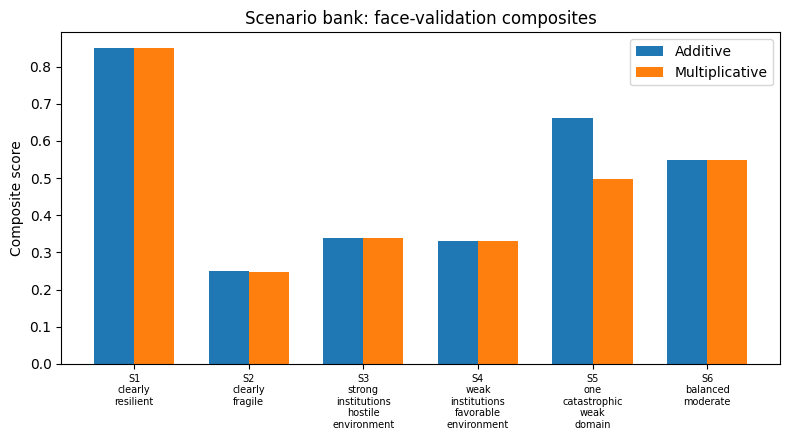

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [s['id'].replace('_', '\n') for s in SCENARIO_BANK]
adds = [scenario_scores[s['id']]['additive'] for s in SCENARIO_BANK]
mults = [scenario_scores[s['id']]['multiplicative'] for s in SCENARIO_BANK]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, adds, width, label='Additive')
ax.bar(x + width/2, mults, width, label='Multiplicative')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('Composite score')
ax.set_title('Scenario bank: face-validation composites')
ax.legend()
plt.tight_layout()
plt.savefig('scenario_bank.png', dpi=110)
plt.show()


## 6. Level 5 — Monte Carlo Weight-Sensitivity Robustness Testing

Flagship demo, tied directly to the reviewer's own worked example: Scenario A =
`[.9, .9, .3]` vs. Scenario B = `[.7, .7, .7]`, equal baseline weights. 5,000
Dirichlet-perturbed weight draws around the baseline simulate "reasonable experts
disagreeing about the weights."

**The question that matters:** does Scenario A still beat Scenario B across most
plausible weightings — or does the ranking flip depending on which weights (or which
aggregation form) you happened to pick?


In [10]:
domains_a = [0.9, 0.9, 0.3]
domains_b = [0.7, 0.7, 0.7]
baseline_betas = [1/3, 1/3, 1/3]

mc_additive = monte_carlo_ranking_sensitivity(domains_a, domains_b, baseline_betas,
                                               aggregation='additive', concentration=200, n_trials=5000, seed=42)
mc_mult = monte_carlo_ranking_sensitivity(domains_a, domains_b, baseline_betas,
                                           aggregation='multiplicative', concentration=200, n_trials=5000, seed=42)

print(f"Scenario A domains={domains_a}  vs  Scenario B domains={domains_b}")
print(f"Baseline weights={baseline_betas}, 5000 Dirichlet-perturbed draws (concentration=200)\n")
print(f"Additive form:       A beats B in {mc_additive['a_wins_fraction']*100:.1f}% of plausible weightings")
print(f"Multiplicative form: A beats B in {mc_mult['a_wins_fraction']*100:.1f}% of plausible weightings")
print("\nA ~50% split (additive) vs. a near-0% split (multiplicative) on the SAME domain")
print("scores and the SAME baseline weights means the aggregation-form choice is doing")
print("more work than the weight uncertainty is. That is a modeling decision to make")
print("deliberately, not a coin flip to leave implicit in the code.")


Scenario A domains=[0.9, 0.9, 0.3]  vs  Scenario B domains=[0.7, 0.7, 0.7]
Baseline weights=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333], 5000 Dirichlet-perturbed draws (concentration=200)

Additive form:       A beats B in 50.6% of plausible weightings
Multiplicative form: A beats B in 0.1% of plausible weightings

A ~50% split (additive) vs. a near-0% split (multiplicative) on the SAME domain
scores and the SAME baseline weights means the aggregation-form choice is doing
more work than the weight uncertainty is. That is a modeling decision to make
deliberately, not a coin flip to leave implicit in the code.


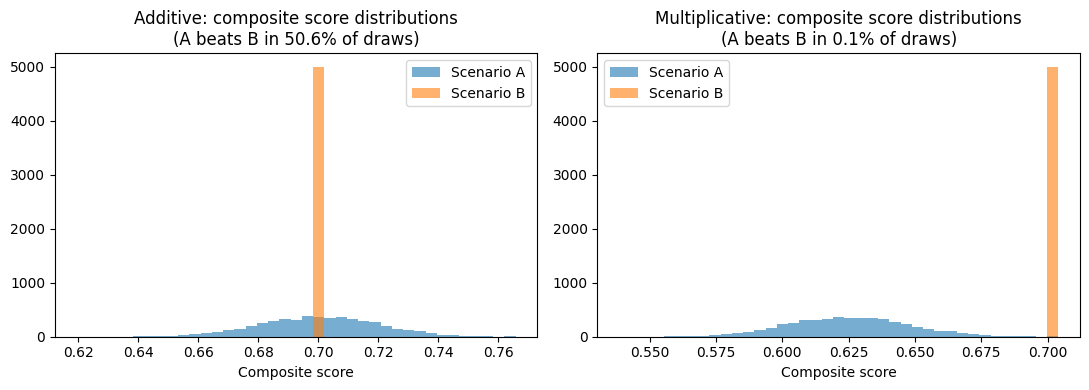

In [11]:
# Note: Scenario B = [.7,.7,.7] is degenerate under the multiplicative form —
# 0.7^b1 * 0.7^b2 * 0.7^b3 = 0.7^(b1+b2+b3) = 0.7^1 = 0.7 for ANY weights that sum to 1.
# So Scenario B's multiplicative score has zero variance under weight perturbation; this
# is itself a finding (equal-domain scenarios are, by construction, weight-invariant
# under the multiplicative form), not a plotting bug. Handle the degenerate range safely.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mc, title in [(axes[0], mc_additive, 'Additive'), (axes[1], mc_mult, 'Multiplicative')]:
    combined = np.concatenate([mc['scores_a'], mc['scores_b']])
    lo, hi = combined.min(), combined.max()
    if np.isclose(lo, hi):
        lo, hi = lo - 0.01, hi + 0.01
    bin_edges = np.linspace(lo, hi, 40)
    ax.hist(mc['scores_a'], bins=bin_edges, alpha=0.6, label='Scenario A')
    ax.hist(mc['scores_b'], bins=bin_edges, alpha=0.6, label='Scenario B')
    ax.set_title(f'{title}: composite score distributions\n(A beats B in {mc["a_wins_fraction"]*100:.1f}% of draws)')
    ax.set_xlabel('Composite score')
    ax.legend()
plt.tight_layout()
plt.savefig('monte_carlo_sensitivity.png', dpi=110)
plt.show()


## 7. Summary Report

All results, gathered into one table and exported to CSV so this notebook's results can
be diffed against a run of the same test_cases.py against a different implementation
(Lyra, WinterStorm2030, StressPoint, Orion, ...).


In [12]:
df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 160)

n_total = len(df)
n_pass = int(df['passed'].sum())
n_fail = n_total - n_pass
n_flagged = int(df['assumption_flagged'].sum())
n_flagged_pass = int(df[df['assumption_flagged']]['passed'].sum())

print(f"Total checks: {n_total}   Passed: {n_pass}   Failed: {n_fail}")
print(f"Assumption-flagged (Stratum II placeholder): {n_flagged} ({n_flagged_pass} passed against the placeholder)")

df.to_csv('auracelle_harness_results.csv', index=False)
print("\nWritten to auracelle_harness_results.csv")

df[['id', 'stratum', 'passed', 'expected', 'actual', 'assumption_flagged']]


Total checks: 28   Passed: 28   Failed: 0
Assumption-flagged (Stratum II placeholder): 2 (2 passed against the placeholder)

Written to auracelle_harness_results.csv


,id,stratum,passed,expected,actual,assumption_flagged
0,I-1_baseline,I,True,0.539915,5.399149e-01,False
1,I-2_all_zero_inputs,I,True,0.377541,3.775407e-01,False
2,I-3_all_one_inputs,I,True,0.622459,6.224593e-01,False
3,I-4_theta_zero_midpoint,I,True,0.622459,6.224593e-01,False
4,I-5_monotonicity_high_weight_indicator,I,True,0.552308,5.523079e-01,False
5,I-6_monotonicity_low_weight_indicator,I,True,0.544879,5.448789e-01,False
6,I-7_exact_threshold_crossing,I,True,0.500000,5.000000e-01,False
7,I-17_zero_zero_calibration,I,True,0.500000,5.000000e-01,False
8,I-18_theta_equals_max_possible_score,I,True,0.500000,5.000000e-01,False
9,I-19_saturation_positive,I,True,1.000000,1.000000e+00,False


### Using this against Lyra / WinterStorm2030 / StressPoint / Orion

This notebook and `test_cases.py` are implementation-agnostic — the hand-derived
`expected` values don't depend on `harness_core.py`. To validate another
implementation:

1. Write a thin adapter exposing that implementation's NOF/Domain/Composite/EOC
   functions with the same signatures as `harness_core.py`.
2. Re-run the `check()` calls above against the adapter instead of `harness_core`.
3. Diff the resulting `auracelle_harness_results.csv` against this run's — any case
   that passes here but fails there is either a genuine implementation bug, or a sign
   that implementation made a different (undocumented) choice on an assumption-flagged
   case.

### Open items this harness surfaced for the methodological review

- **Stratum II has no disclosed aggregation formula** — confirm the real one before
  trusting any Stratum II/III/IV result downstream of it.
- **Additive vs. multiplicative divergence is large and scenario-dependent** — the
  Monte Carlo demo above (50.6% vs. 0.1%) shows this is not a minor implementation
  detail; it should be a stated, deliberate modeling choice.
- **EOC's upper bound (enhancement above 1.0) is unconfirmed** — flagged in scenario
  S4, not used anywhere else in this harness.
- **No uncertainty is currently propagated through the composite score** — per the
  review, consider reporting an interval or probability-of-exceeding-threshold rather
  than a bare point estimate once empirical data exists.
